In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Carga y exploración de los datos

In [55]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=";")

df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [56]:
df.info

<bound method DataFrame.info of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067

In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


# variable objetivo (label)

In [58]:
def quality_to_label(q):
    if q <= 4:
        return 0   
    elif q <= 6:
        return 1   
    else:
        return 2   

df["label"] = df["quality"].apply(quality_to_label)

<Axes: xlabel='label'>

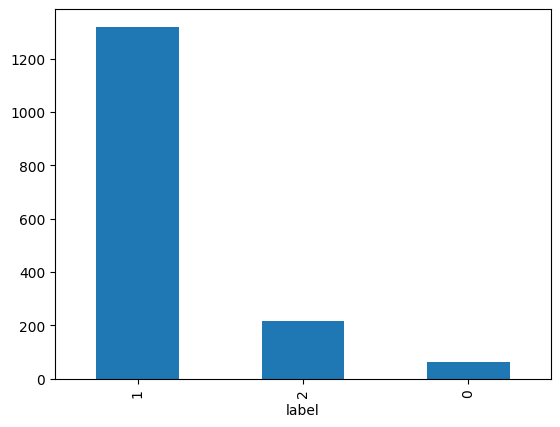

In [59]:
df["label"].value_counts().plot(kind="bar")

# Separación de variables independientes y objetivo

In [60]:
X = df.drop(columns=["quality", "label"])
y = df["label"]

# Split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado

In [62]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamiento del modelo KNN

In [63]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

# Evaluación del modelo inicial

In [64]:
accuracy_score(y_test, y_pred)

0.81875

# Matriz de confusión

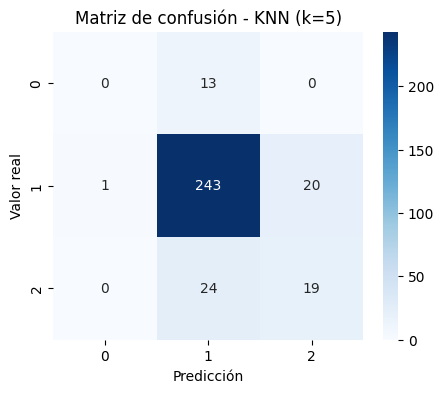

In [65]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - KNN (k=5)")
plt.show()

In [66]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.00      0.00      0.00        13\n           1       0.87      0.92      0.89       264\n           2       0.49      0.44      0.46        43\n\n    accuracy                           0.82       320\n   macro avg       0.45      0.45      0.45       320\nweighted avg       0.78      0.82      0.80       320\n'

# Optimización del valor de k

In [67]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_k_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_k_pred))

# Gráfica: Accuracy vs k

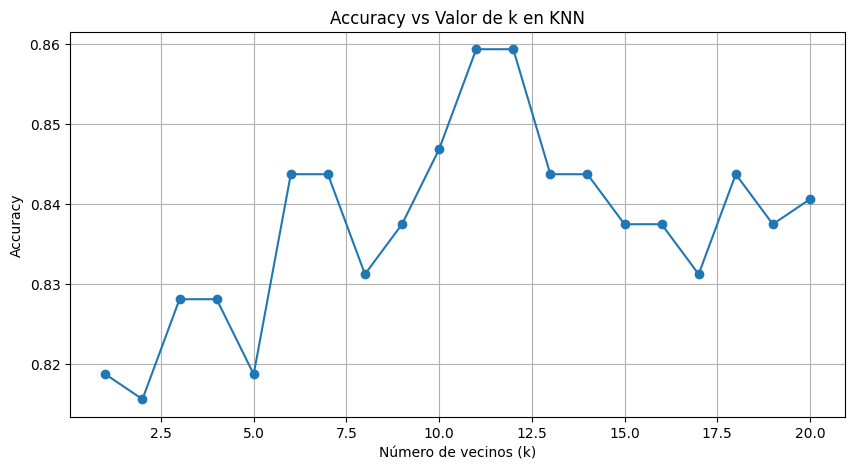

In [68]:
plt.figure(figsize=(10,5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Valor de k en KNN")
plt.grid(True)
plt.show()

# Selección del mejor k

In [69]:
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

best_k, best_accuracy

(11, 0.859375)

# Entrenamiento del modelo final

In [70]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

y_pred_final = final_knn.predict(X_test_scaled)

In [71]:
accuracy_score(y_test, y_pred_final)

0.859375

# Función para predecir la calidad de un vino

In [72]:
def predict_wine_quality(features):
    features_scaled = scaler.transform([features])
    prediction = final_knn.predict(features_scaled)[0]

    if prediction == 0:
        return "Este vino probablemente sea de baja calidad"
    elif prediction == 1:
        return "Este vino probablemente sea de calidad media"
    else:
        return "Este vino probablemente sea de alta calidad"


# Ejemplo

In [73]:
resultado = predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076,11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])

resultado

/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'Este vino probablemente sea de calidad media'